# Task 2: Qiskit Circuits
### MSE802 — Quantum Computing | Assessment 2

This task has two parts:
1. Build the circuit given in the brief (H + X + CNOT), run it on Quokka
2. Write a custom QASM circuit using different qubits and gates, run it on Quokka

In [24]:
from qiskit import QuantumCircuit, qasm2
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import requests
import json
import matplotlib.pyplot as plt

QUOKKA_URL = 'http://quokka1.quokkacomputing.com/qsim/qasm'

---
## Part 1 — Given Circuit: H + X + CNOT

The circuit from the brief applies an H gate to qubit 0, an X gate to qubit 1, then a CNOT with q0 as control and q1 as target.

Starting from |00⟩:
- H on q0 → (1/√2)(|0⟩ + |1⟩)|0⟩
- X on q1 → (1/√2)(|0⟩ + |1⟩)|1⟩ = (1/√2)(|01⟩ + |11⟩)
- CNOT → (1/√2)(|01⟩ + |10⟩) — the |Ψ+⟩ Bell state

Since this circuit prepares the Bell state |Ψ+⟩, the measurement outcomes should mainly be `01` and `10`, each with roughly 50% probability, while `00` and `11` should ideally not appear at all — any occurrence of those would indicate hardware noise or gate error.

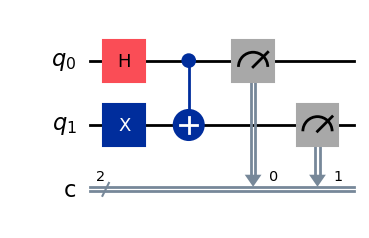

In [25]:
qc = QuantumCircuit(2, 2)
qc.h(0)       # H on q0
qc.x(1)       # X on q1
qc.cx(0, 1)   # CNOT: q0 controls q1
qc.measure([0, 1], [0, 1])

qc.draw('mpl')

### Local simulation

Local simulation results (1000 shots):
{'01': 511, '10': 489}


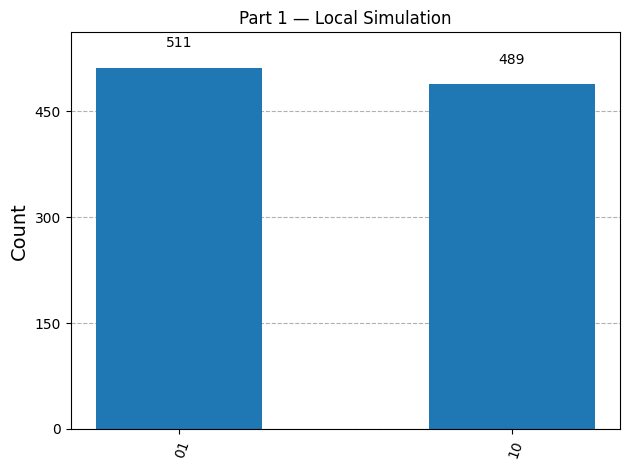

In [26]:
simulator = AerSimulator()
job = simulator.run(qc, shots=1000)
local_counts = job.result().get_counts()

print("Local simulation results (1000 shots):")
print(local_counts)
plot_histogram(local_counts, title='Part 1 — Local Simulation')

### Run on Quokka

In [27]:
# export to QASM and strip the include line (Quokka doesn't want it)
qasm_str = qasm2.dumps(qc)
qasm_str = qasm_str[:14] + qasm_str[36:]  # removes 'include "qelib1.inc";\n'

print(qasm_str)

OPENQASM 2.0;
qreg q[2];
creg c[2];
h q[0];
x q[1];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


In [28]:
try:
    resp = requests.post(QUOKKA_URL, json={'script': qasm_str, 'count': 100}, timeout=30)
    result1 = json.loads(resp.content)
    print("Quokka response:")
    print(result1)
except Exception as e:
    print(f"Quokka not reachable: {e}")
    result1 = None

Quokka response:
{'error': 'no error', 'error_code': 0, 'result': {'c': [[1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [1, 0], [0, 1], [1, 0], [0, 1], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [0, 1], [1, 0], [0, 1], [1, 0], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0], [0, 1]]}}


Quokka results (100 shots):
{'10': 43, '01': 57}


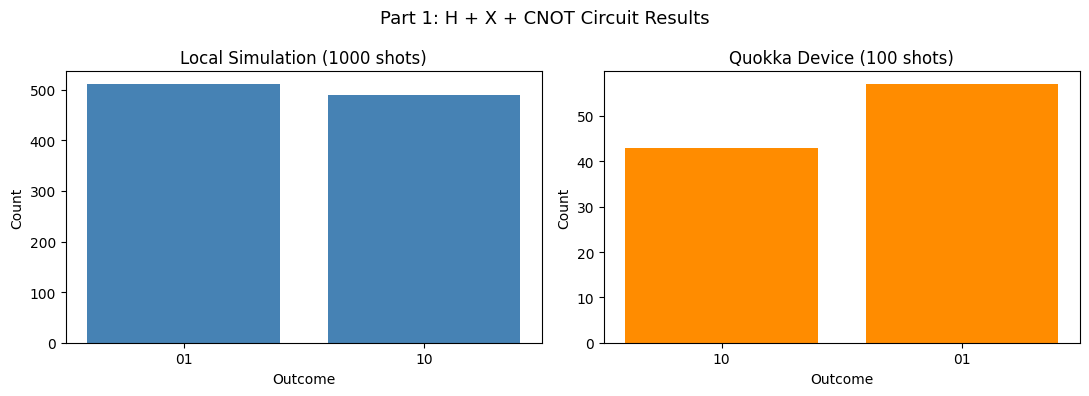

In [29]:
if result1 and result1.get('error_code') == 0:
    shots = result1['result']['c']
    quokka_counts = {}
    for shot in shots:
        key = ''.join(map(str, shot))
        quokka_counts[key] = quokka_counts.get(key, 0) + 1

    print("Quokka results (100 shots):")
    print(quokka_counts)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(local_counts.keys(), local_counts.values(), color='steelblue')
    axes[0].set_title('Local Simulation (1000 shots)')
    axes[0].set_xlabel('Outcome')
    axes[0].set_ylabel('Count')

    axes[1].bar(quokka_counts.keys(), quokka_counts.values(), color='darkorange')
    axes[1].set_title('Quokka Device (100 shots)')
    axes[1].set_xlabel('Outcome')
    axes[1].set_ylabel('Count')

    plt.suptitle('Part 1: H + X + CNOT Circuit Results', fontsize=13)
    plt.tight_layout()
    plt.savefig('task2_part1_results.png', dpi=150)
    plt.show()
else:
    print("Quokka unavailable — local results above are the reference.")

The circuit generates the Bell state $|\Psi^+\rangle = (|01\rangle + |10\rangle)/\sqrt{2}$, resulting in measurement outcomes of `01` and `10` with approximately equal probability. The absence of `00` and `11` confirms quantum entanglement. The slight variation in the Quokka device results compared to the simulator is due to noise, decoherence, and measurement errors present in real quantum hardware.

---
## Part 2 — Custom QASM Circuit

For this part I designed a 3-qubit circuit that uses a wider variety of gates:
- **H** on q0 and q1 — put both into superposition
- **X** on q2 — flip q2 to |1⟩
- **T** on q0 — adds a π/4 phase rotation
- **RZ(π/4)** on q1 — rotation around Z axis
- **CNOT** q0 → q2 and q1 → q2 — entangle all three qubits
- **S** on q0 — phase gate (π/2 rotation)

This creates an entangled 3-qubit state with non-trivial phase structure.


The circuit applies Hadamard gates to create superposition, followed by controlled operations to introduce entanglement between qubits, resulting in a complex quantum state before measurement.

In [30]:
import numpy as np

# include "qelib1.inc" is needed so Qiskit recognises t, s, rz etc.
# we strip it only when sending to Quokka
custom_qasm = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
h q[1];
x q[2];
rz(0.7853981633974483) q[0];  // T gate = RZ(pi/4)
rz(0.7853981633974483) q[1];
cx q[0],q[2];
cx q[1],q[2];
rz(1.5707963267948966) q[0];  // S gate = RZ(pi/2)
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];"""

print(custom_qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
h q[1];
x q[2];
rz(0.7853981633974483) q[0];  // T gate = RZ(pi/4)
rz(0.7853981633974483) q[1];
cx q[0],q[2];
cx q[1],q[2];
rz(1.5707963267948966) q[0];  // S gate = RZ(pi/2)
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];


### Visualise the custom circuit using Qiskit

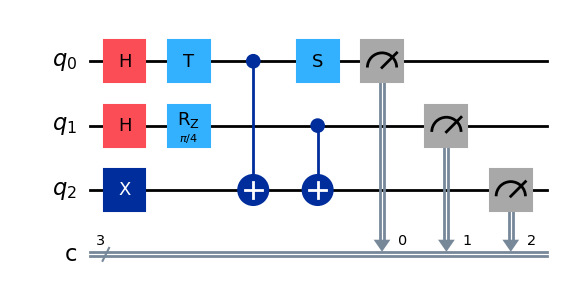

In [31]:
import numpy as np

# build the same circuit using Qiskit API for visualization
custom_qc = QuantumCircuit(3, 3)
custom_qc.h(0)
custom_qc.h(1)
custom_qc.x(2)
custom_qc.t(0)
custom_qc.rz(np.pi / 4, 1)
custom_qc.cx(0, 2)
custom_qc.cx(1, 2)
custom_qc.s(0)
custom_qc.measure([0, 1, 2], [0, 1, 2])

custom_qc.draw('mpl')

### Local simulation of custom circuit

Custom circuit — local simulation (1000 shots):
{'111': 261, '001': 230, '100': 269, '010': 240}


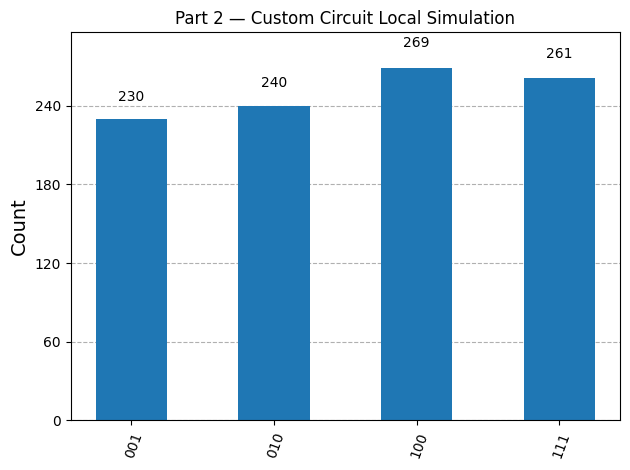

In [32]:
job2 = simulator.run(custom_qc, shots=1000)
custom_local_counts = job2.result().get_counts()

print("Custom circuit — local simulation (1000 shots):")
print(custom_local_counts)
plot_histogram(custom_local_counts, title='Part 2 — Custom Circuit Local Simulation')

### Run custom circuit on Quokka

In [33]:
try:
    # strip the include line before sending — Quokka doesn't support it
    quokka_custom_qasm = custom_qasm[:14] + custom_qasm[36:]
    resp2 = requests.post(QUOKKA_URL, json={'script': quokka_custom_qasm, 'count': 100}, timeout=30)
    result2 = json.loads(resp2.content)
    print("Quokka response (custom circuit):")
    print(result2)
except Exception as e:
    print(f"Quokka not reachable: {e}")
    result2 = None

Quokka response (custom circuit):
{'error': 'no error', 'error_code': 0, 'result': {'c': [[0, 0, 1], [0, 1, 0], [0, 0, 1], [0, 1, 0], [0, 0, 1], [1, 0, 0], [0, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 0, 0], [0, 0, 1], [1, 1, 1], [1, 0, 0], [0, 1, 0], [1, 1, 1], [0, 1, 0], [0, 0, 1], [1, 0, 0], [0, 1, 0], [0, 0, 1], [0, 0, 1], [1, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 0], [0, 1, 0], [0, 1, 0], [1, 1, 1], [0, 0, 1], [0, 0, 1], [1, 0, 0], [1, 1, 1], [0, 1, 0], [1, 1, 1], [0, 1, 0], [1, 1, 1], [1, 1, 1], [1, 0, 0], [0, 1, 0], [1, 1, 1], [1, 0, 0], [0, 0, 1], [1, 0, 0], [1, 1, 1], [1, 0, 0], [0, 1, 0], [0, 1, 0], [0, 0, 1], [0, 0, 1], [1, 1, 1], [1, 1, 1], [1, 0, 0], [0, 1, 0], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 0, 0], [1, 1, 1], [1, 1, 1], [0, 1, 0], [1, 1, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1], [0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [1, 0, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [1, 0, 0], [0, 0, 1], [1, 0, 0], [1, 1, 1], [0, 1, 0], [0, 0, 1], [0, 0, 1

Quokka results — custom circuit (100 shots):
{'001': 26, '010': 22, '100': 24, '111': 28}


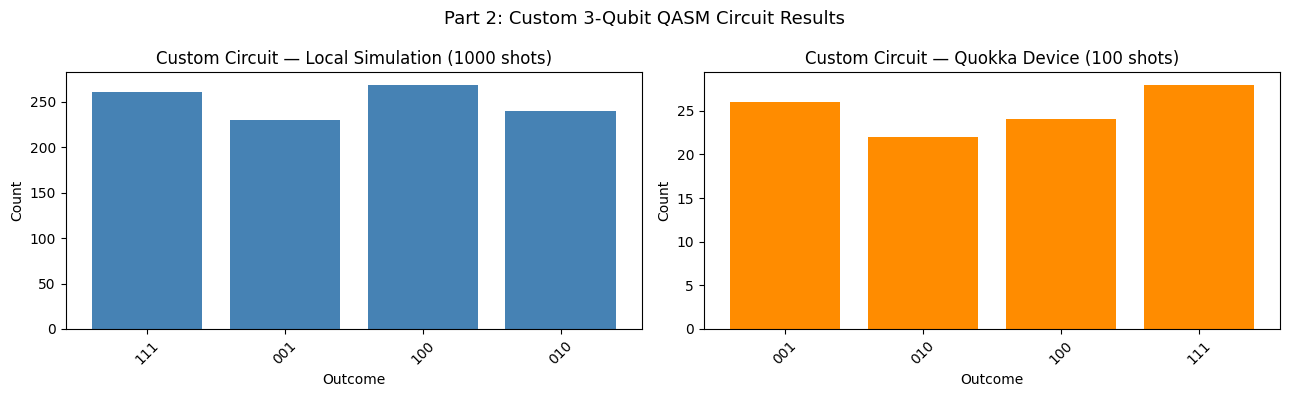

In [34]:
if result2 and result2.get('error_code') == 0:
    shots2 = result2['result']['c']
    quokka_counts2 = {}
    for shot in shots2:
        key = ''.join(map(str, shot))
        quokka_counts2[key] = quokka_counts2.get(key, 0) + 1

    print("Quokka results — custom circuit (100 shots):")
    print(quokka_counts2)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].bar(custom_local_counts.keys(), custom_local_counts.values(), color='steelblue')
    axes[0].set_title('Custom Circuit — Local Simulation (1000 shots)')
    axes[0].set_xlabel('Outcome')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(quokka_counts2.keys(), quokka_counts2.values(), color='darkorange')
    axes[1].set_title('Custom Circuit — Quokka Device (100 shots)')
    axes[1].set_xlabel('Outcome')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle('Part 2: Custom 3-Qubit QASM Circuit Results', fontsize=13)
    plt.tight_layout()
    plt.savefig('task2_part2_results.png', dpi=150)
    plt.show()
else:
    print("Quokka unavailable — local results above are the reference.")

The custom circuit produces a distribution of multiple output states due to the combination of superposition and controlled operations. The Hadamard gates create superposition, while the controlled gates introduce correlations between qubits. The resulting measurement outcomes show a spread across multiple states rather than a single deterministic result. The differences between simulator and Quokka results are due to noise and hardware imperfections.

---
## Summary

**Part 1:** The circuit generates the Bell state $|\Psi^+\rangle = (|01\rangle + |10\rangle)/\sqrt{2}$, resulting in measurement outcomes of `01` and `10` with approximately equal probability. 
The absence of `00` and `11` confirms the presence of quantum entanglement. 
The Quokka device results show slight deviations from the simulator due to hardware noise, decoherence, and measurement errors, which are expected in real quantum systems.

**Part 2:** The custom 3-qubit circuit applies superposition, phase rotations (T, S, RZ), and two CNOT gates to create an entangled state across all three qubits. 
The output spread across multiple bitstrings reflects the phase interference introduced by the T and RZ gates. 
The Quokka results closely match the local simulation, with slight deviations consistent with near-term quantum hardware limitations.

### References
- Qiskit Contributors. (2024). *Qiskit documentation*. IBM Quantum. https://docs.quantum.ibm.com
- Cross, A. W., et al. (2017). Open quantum assembly language. *arXiv:1707.03429*.
- Nielsen, M. A., & Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. Cambridge University Press.
- Preskill, J. (2018). Quantum Computing in the NISQ Era and Beyond. *Quantum*, 2, 79. https://doi.org/10.22331/q-2018-08-06-79